DATA INGESTION

Importing all necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile
import os 
import seaborn as sns

In [2]:
path= r"playground-series-s5e11 (1).zip"

In [3]:
def load_path(path):
    with ZipFile(path, 'r') as ref:
        ref.printdir()

In [4]:
load_path(path)

File Name                                             Modified             Size
sample_submission.csv                          2025-10-28 23:08:48      2291139
test.csv                                       2025-10-28 23:08:48     23021430
train.csv                                      2025-10-28 23:08:50     55988519


In [5]:
# with ZipFile(path) as z:
#     with z.open("train.csv") as f:
#         file=pd.read_csv(f, sep=",")

In [6]:
def load_file(data):
    with ZipFile(data) as z:
        with z.open("train.csv") as f:
         file=pd.read_csv(f, sep=",")
         return file

In [7]:
df= load_file(path)


PREMILARY DATA ANALYSIS

In [8]:
df.head(5)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [9]:
# gender, marital_status, educatin_level, employment_status, loan_purpose, 

In [10]:
df= df.drop(columns=["id"])


In [11]:

df.columns

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'gender', 'marital_status', 'education_level',
       'employment_status', 'loan_purpose', 'grade_subgrade',
       'loan_paid_back'],
      dtype='object')

DESCRIPTIVE DATA ANALYSIS

In [12]:
df.isna().sum()

annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [13]:
df.shape

(593994, 12)

In [14]:
df.describe().T.style.background_gradient()

,count,mean,std,min,25%,50%,75%,max
annual_income,593994.000000,48212.202976,26711.942078,6002.430000,27934.400000,46557.680000,60981.320000,393381.740000
debt_to_income_ratio,593994.000000,0.120696,0.068573,0.011000,0.072000,0.096000,0.156000,0.627000
credit_score,593994.000000,680.916009,55.424956,395.000000,646.000000,682.000000,719.000000,849.000000
loan_amount,593994.000000,15020.297629,6926.530568,500.090000,10279.620000,15000.220000,18858.580000,48959.950000
interest_rate,593994.000000,12.356345,2.008959,3.200000,10.990000,12.370000,13.680000,20.990000
loan_paid_back,593994.000000,0.798820,0.400883,0.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  object 
 6   marital_status        593994 non-null  object 
 7   education_level       593994 non-null  object 
 8   employment_status     593994 non-null  object 
 9   loan_purpose          593994 non-null  object 
 10  grade_subgrade        593994 non-null  object 
 11  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 54.4+ MB


EXPLORATORY DATA ANALYSIS

In [16]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
593989    False
593990    False
593991    False
593992    False
593993    False
Length: 593994, dtype: bool

In [17]:
df.dtypes

annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                   object
marital_status           object
education_level          object
employment_status        object
loan_purpose             object
grade_subgrade           object
loan_paid_back          float64
dtype: object

In [18]:
# Making list of all categorical dataset
cat_col= list(df.select_dtypes("object").columns)
for col in cat_col:
    print(df[col].value_counts())
    print("--"*50)

gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
marital_status
Single      288843
Married     277239
Divorced     21312
Widowed       6600
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
employment_status
Employed         450645
Unemployed        62485
Self-employed     52480
Retired           16453
Student           11931
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
loan_purpose
Debt consolidation    324695
Other                  63874
Car     

In [19]:
numerical_features=df.select_dtypes(include=['number']).columns
numerical_features

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back'],
      dtype='object')

In [20]:
cat_features= df.select_dtypes(include=['object']).columns
cat_features

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

# Univariate Analysis

In [21]:
def histogram_boxplot(df, feature, figsize=(12, 8), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=df, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        df[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        df[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram
    plt.tight_layout()
    plt.show()

In [22]:
# Create a copy for preprocessing
df = df.copy()



# 1. Check for missing values (EDA showed no missing values)
print("\n1. Missing Values:")
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No missing values found (as expected from EDA)")

# 2. Check for duplicates
print("\n2. Duplicate Rows:")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage of duplicates: {(duplicates/len(data))*100:.2f}%")

# 3. Check skewness for variables identified in EDA as right-skewed
print("\n3. Skewness Analysis (EDA identified right-skewed variables):")
skewed_vars = ['no_of_employees', 'prevailing_wage', 'yr_of_estab']
for var in skewed_vars:
    if var in df.columns:
        skewness = df[var].skew()
        print(f"{var}: skewness = {skewness:.3f} ({'right-skewed' if skewness > 0.5 else 'approximately normal'})")


1. Missing Values:
No missing values found (as expected from EDA)

2. Duplicate Rows:
Number of duplicate rows: 0

3. Skewness Analysis (EDA identified right-skewed variables):


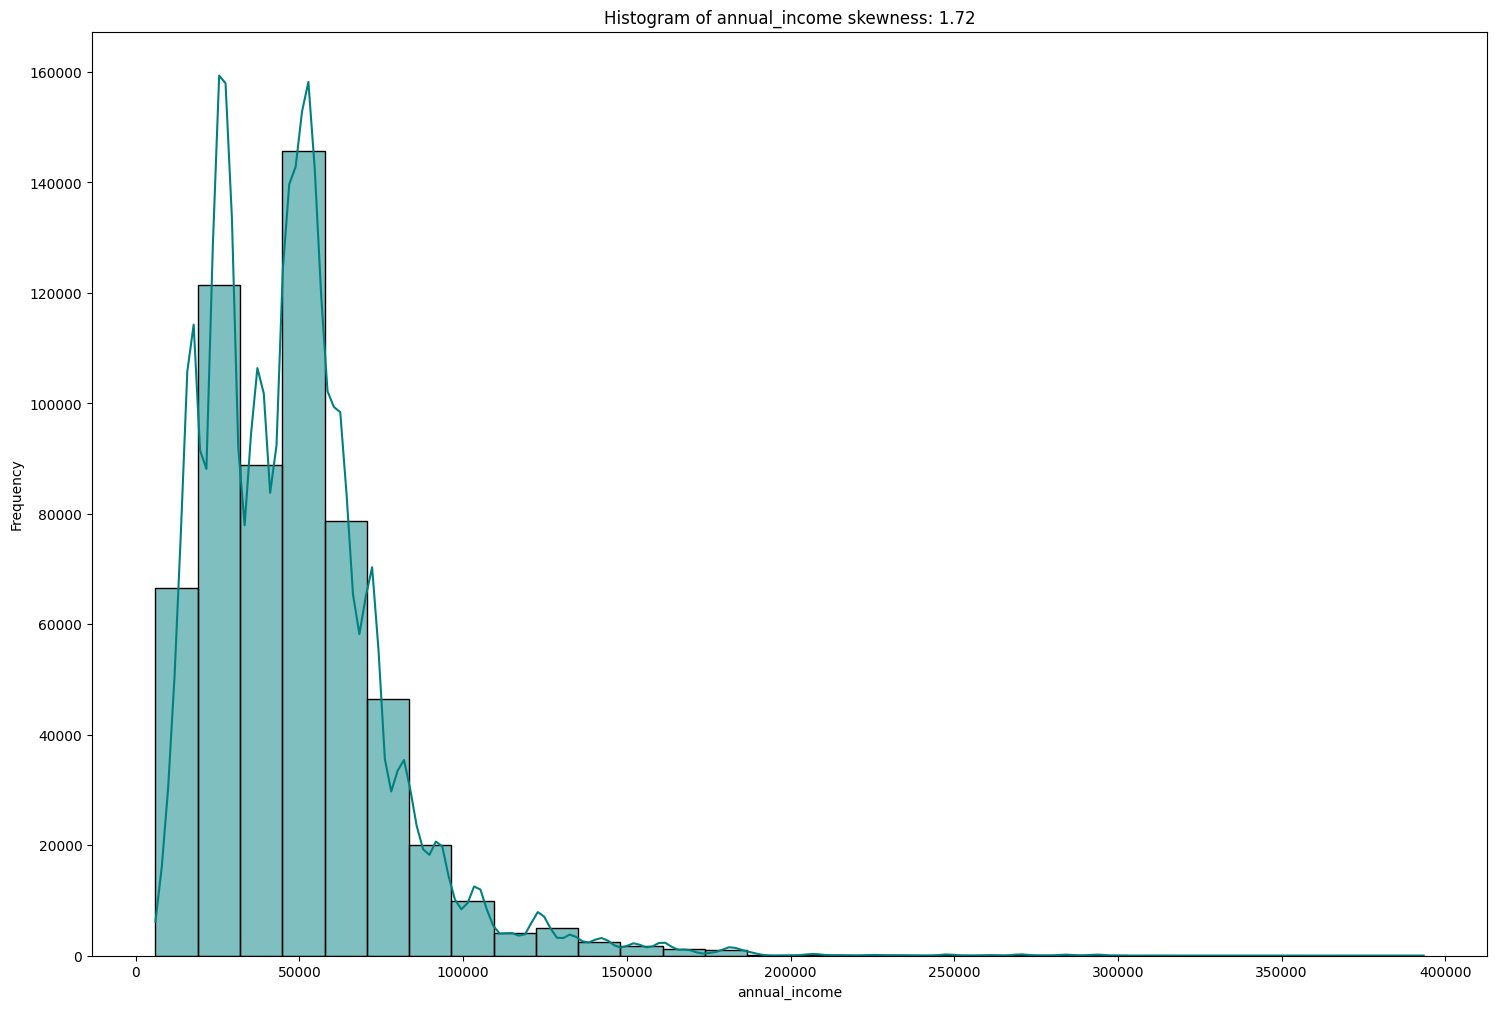

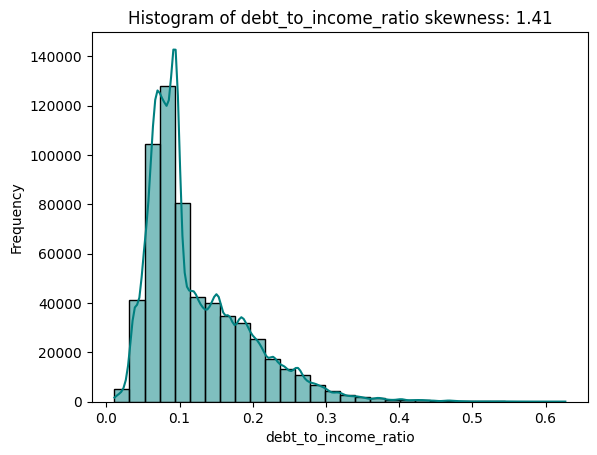

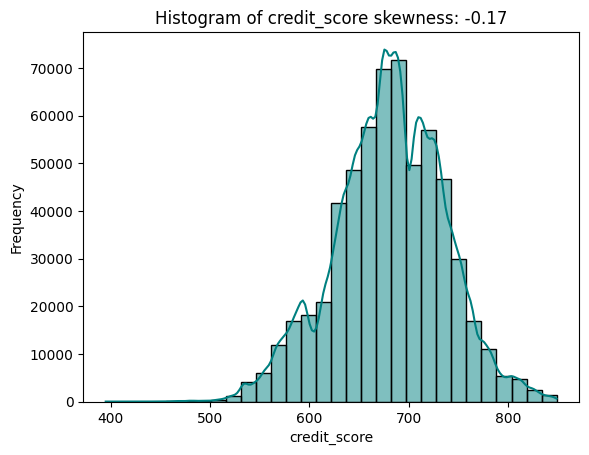

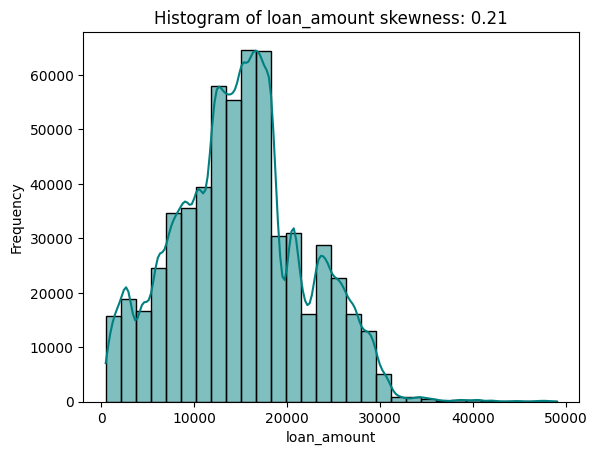

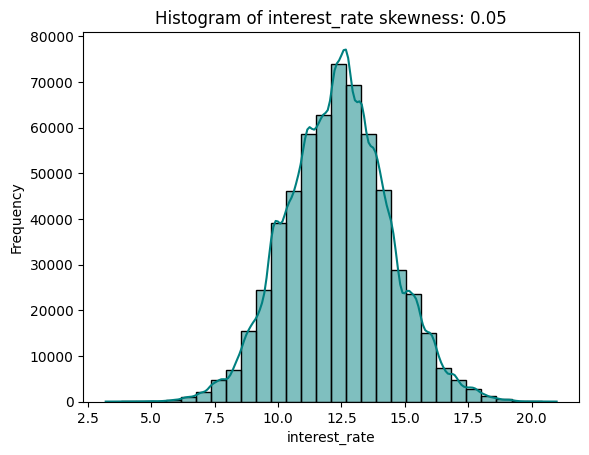

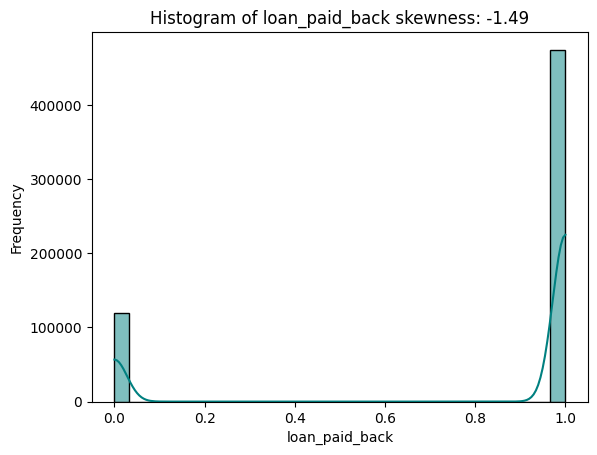

In [23]:
numerical_features= df.select_dtypes(include='number').columns
numerical_features = numerical_features
def histogram_boxplot(df, num_cols):
    
 # For histogram
 #  # Add median to the histogram
    plt.figure(figsize=(18,12))
    for col in num_cols:
        sns.histplot(df[col], bins=30, kde=True, color='teal')
        plt.title(f'Histogram of {col} skewness: {df[col].skew():.2f}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()




histogram_boxplot(df, numerical_features)

In [24]:
def category_check(df, columns):
    for col in columns:
        print(f"{df[col].value_counts()}")
        print("="*50)
        print("")
category_check(df, cat_features)

gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64

marital_status
Single      288843
Married     277239
Divorced     21312
Widowed       6600
Name: count, dtype: int64

education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64

employment_status
Employed         450645
Unemployed        62485
Self-employed     52480
Retired           16453
Student           11931
Name: count, dtype: int64

loan_purpose
Debt consolidation    324695
Other                  63874
Car                    58108
Home                   44118
Education              36641
Business               35303
Medical                22806
Vacation                8449
Name: count, dtype: int64

grade_subgrade
C3    58695
C4    55957
C2    54443
C1    53363
C5    53317
D1    37029
D3    36694
D4    35097
D2    34432
D5    32101
B2    15167
B1    14344
B5    13937
B3    13926
B4    13877
E4     8036


In [25]:
# mapping the col together


In [26]:
def univariate_categories(df, column):
    """
    Performs univariate EDA on a categorical or ordinal column.
    Displays frequency table, proportion, and a countplot.
    """
    print(f"Feature: {column}")
    print("="*40)

    # Frequency + proportion
    freq = df[column].value_counts()
    prop = df[column].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': freq, 'Percentage': prop.round(2)})
    print(summary)
    print()

    # Visualization
    plt.figure(figsize=(18,9))
    ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')
    plt.title(f'Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Count')

    # Annotate each bar with percentage
    total = len(df[column])
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2, height + 1,
                f'{(height/total)*100:.1f}%', ha='center')

    plt.tight_layout()
    plt.show()

Feature: gender


         Count  Percentage
gender                    
Female  306175       51.55
Male    284091       47.83
Other     3728        0.63



C:\Users\User\AppData\Local\Temp\ipykernel_4204\572669563.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


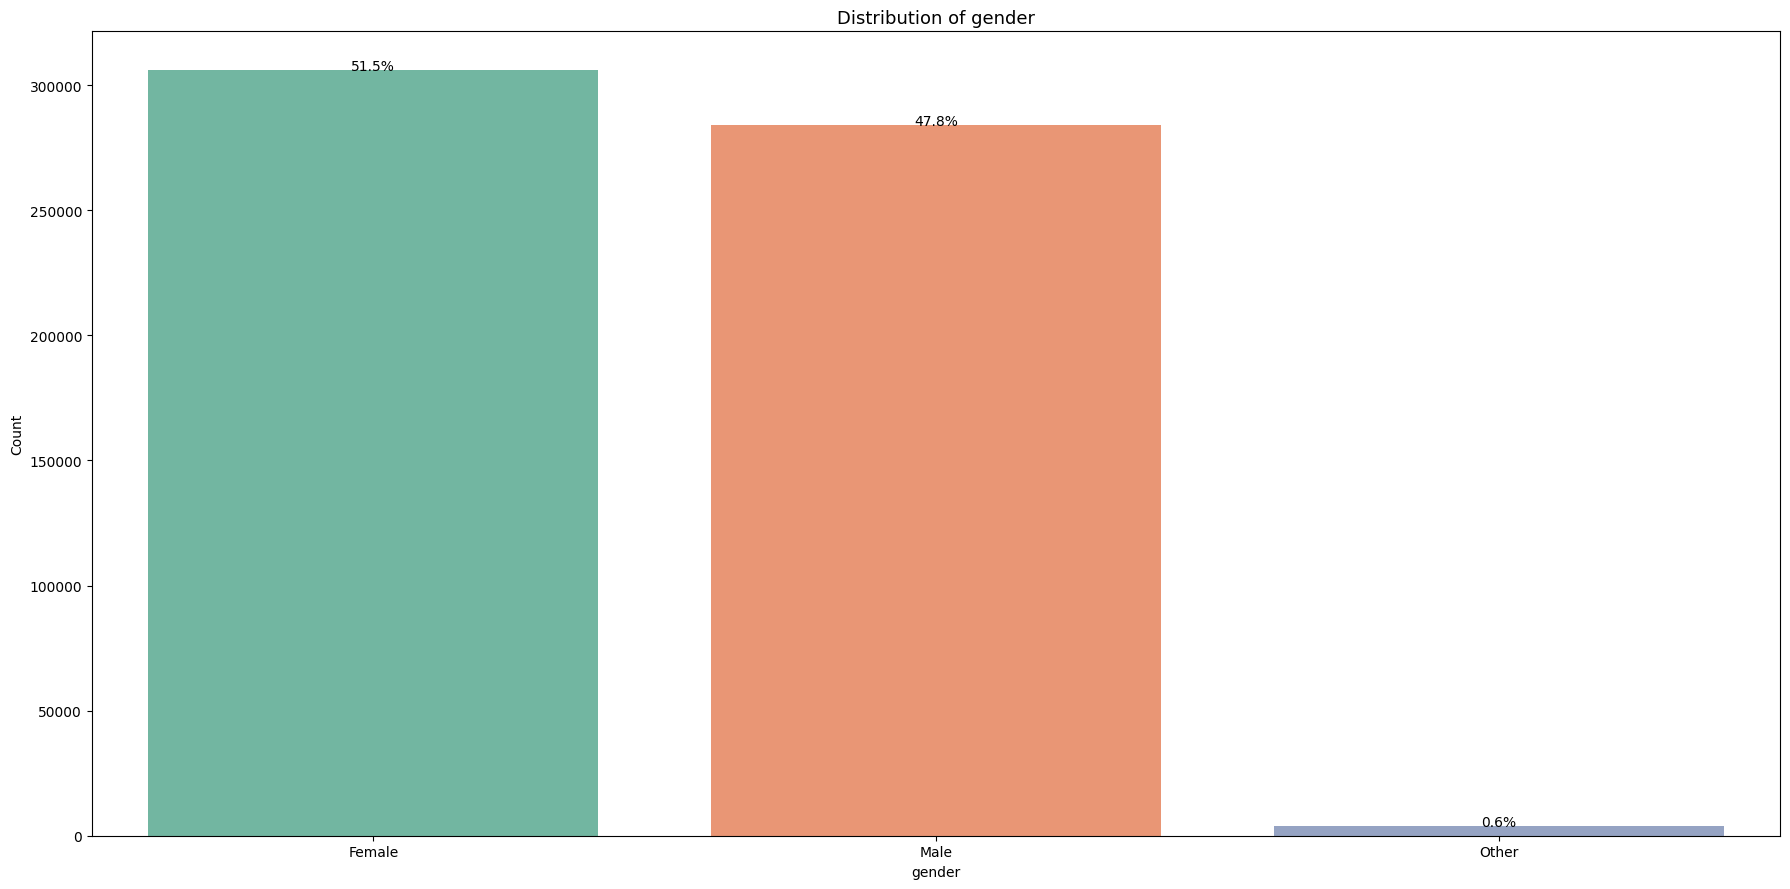

Feature: marital_status
                 Count  Percentage
marital_status                    
Single          288843       48.63
Married         277239       46.67
Divorced         21312        3.59
Widowed           6600        1.11



C:\Users\User\AppData\Local\Temp\ipykernel_4204\572669563.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


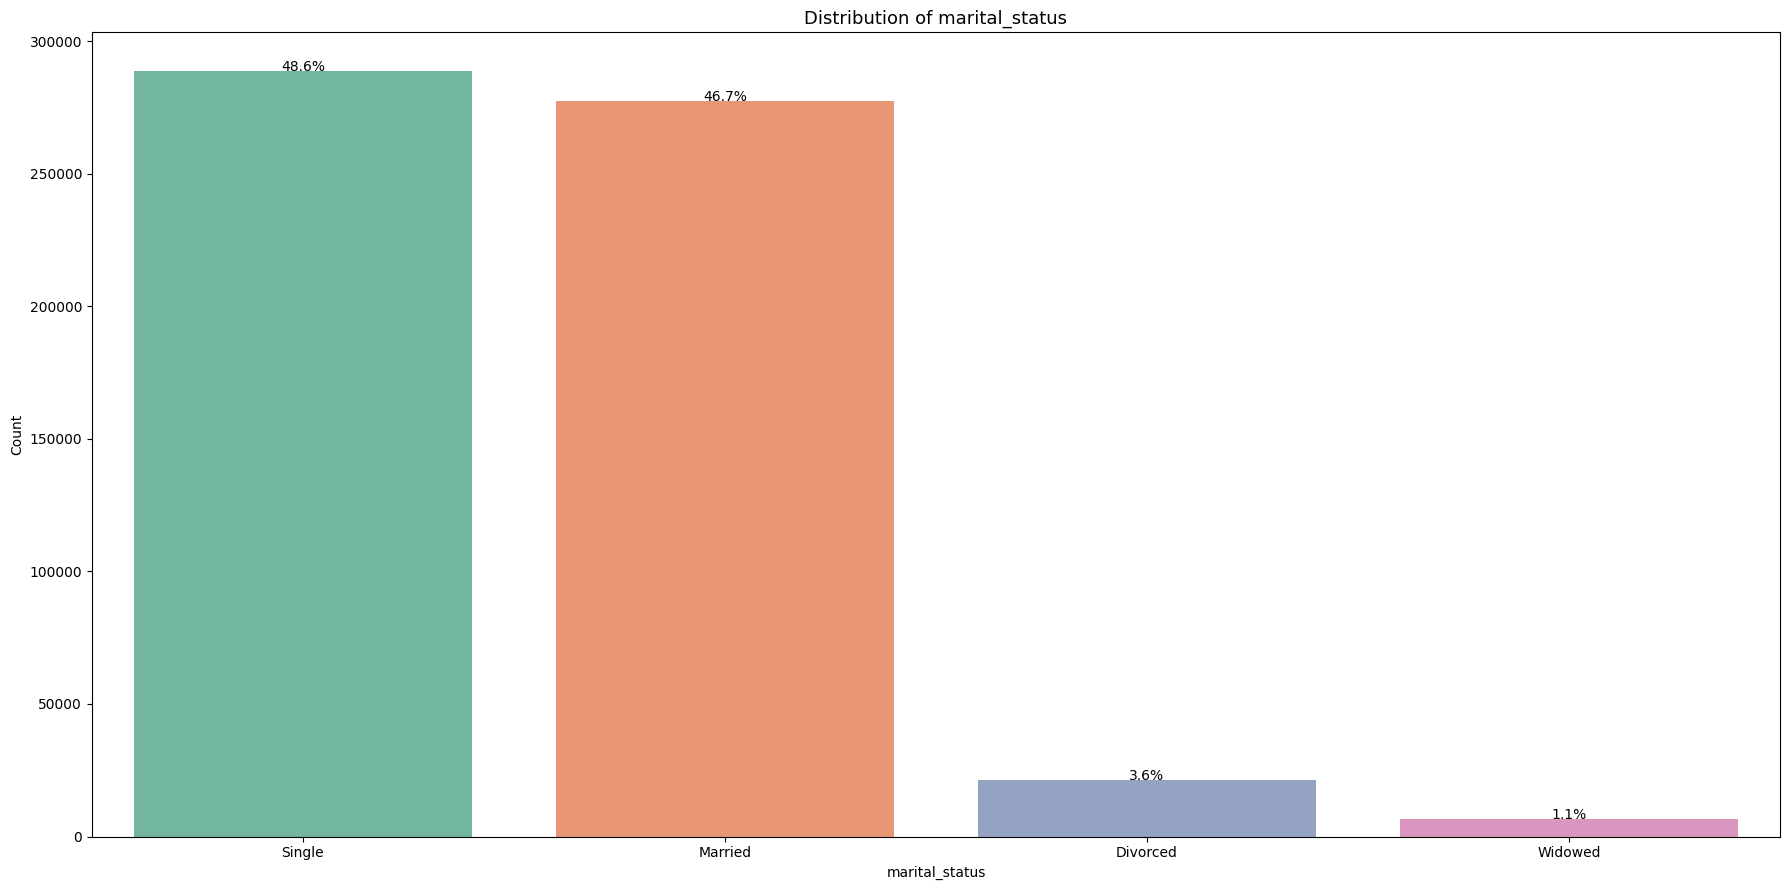

Feature: education_level
                  Count  Percentage
education_level                    
Bachelor's       279606       47.07
High School      183592       30.91
Master's          93097       15.67
Other             26677        4.49
PhD               11022        1.86



C:\Users\User\AppData\Local\Temp\ipykernel_4204\572669563.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


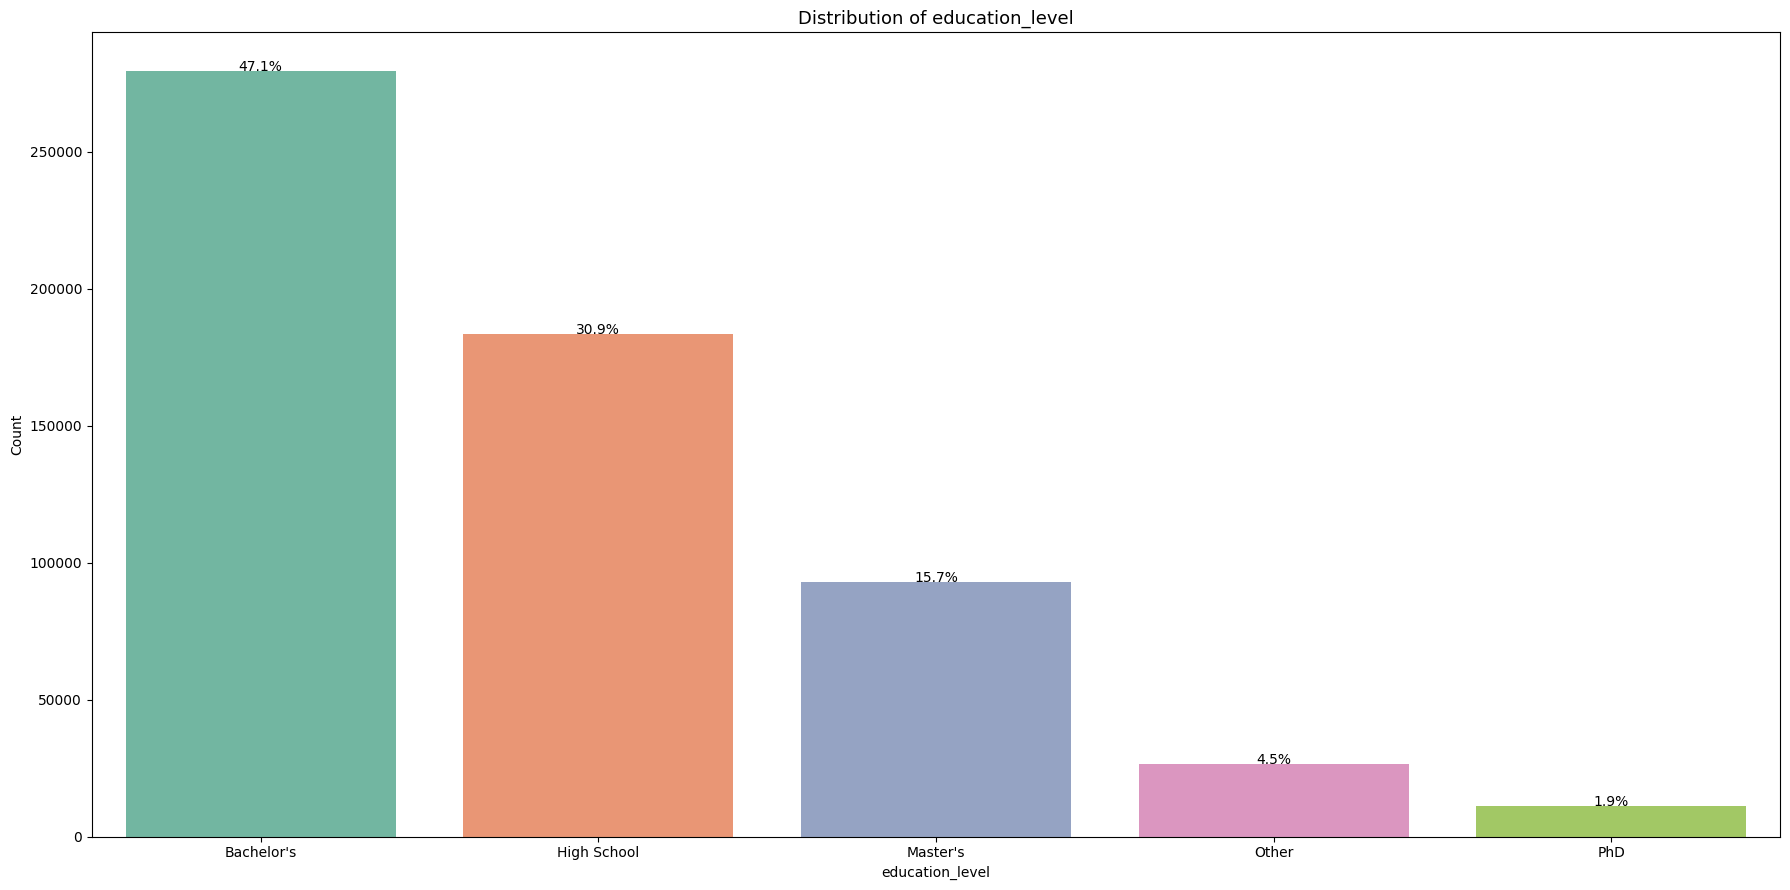

Feature: employment_status
                    Count  Percentage
employment_status                    
Employed           450645       75.87
Unemployed          62485       10.52
Self-employed       52480        8.84
Retired             16453        2.77
Student             11931        2.01



C:\Users\User\AppData\Local\Temp\ipykernel_4204\572669563.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


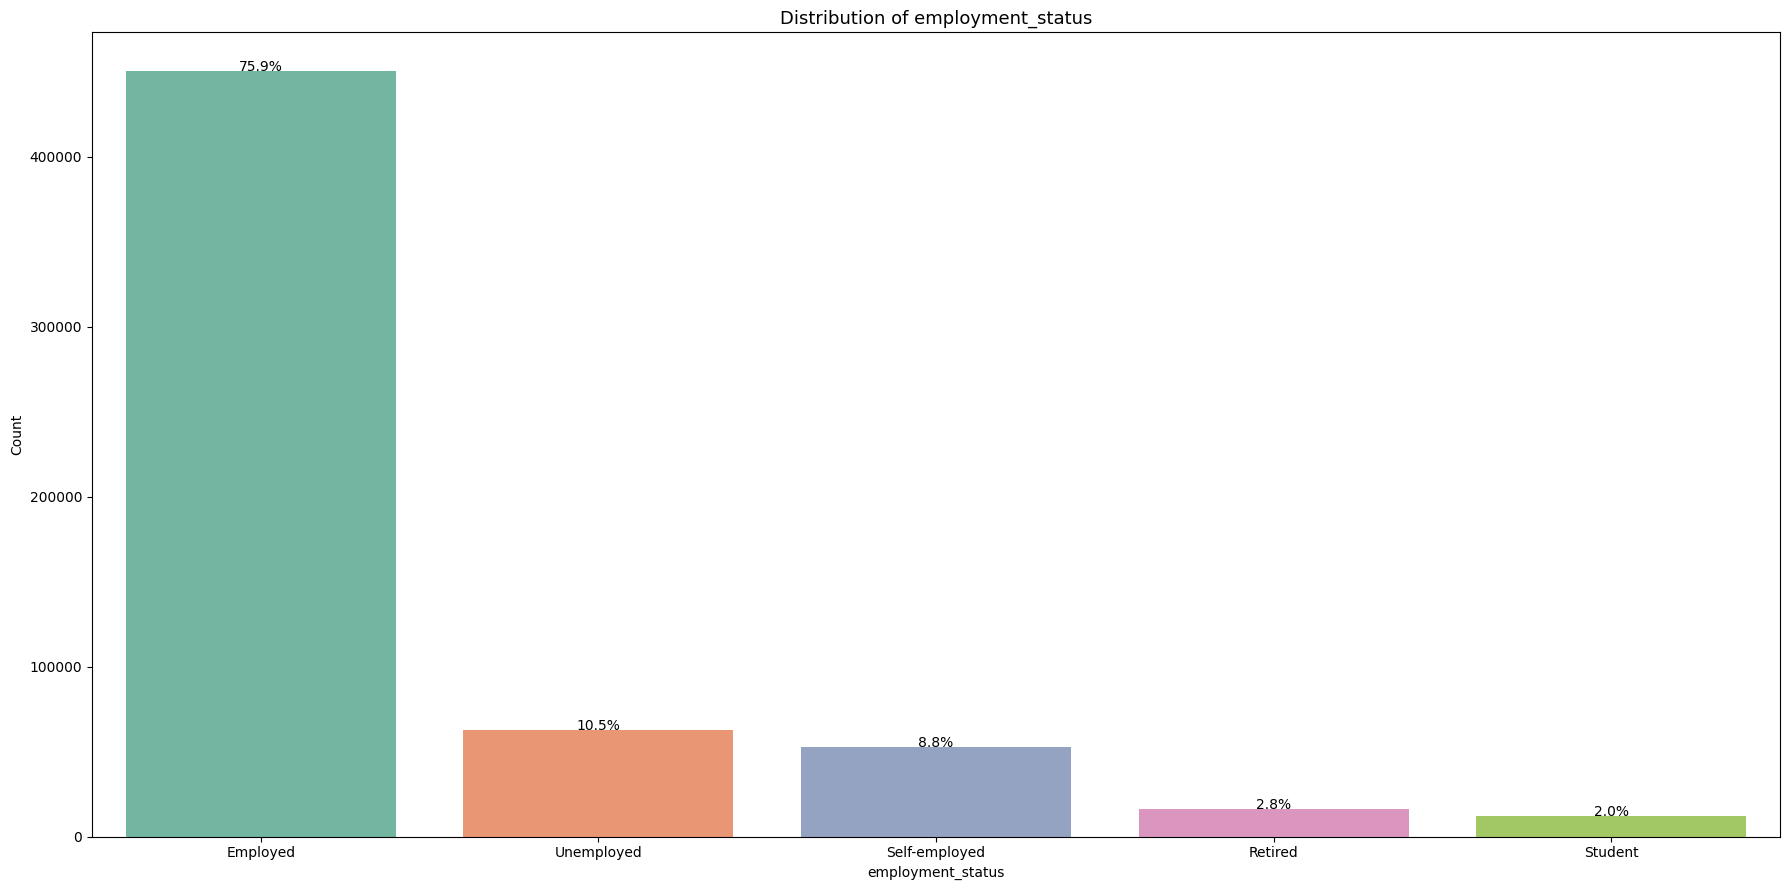

Feature: loan_purpose
                     Count  Percentage
loan_purpose                          
Debt consolidation  324695       54.66
Other                63874       10.75
Car                  58108        9.78
Home                 44118        7.43
Education            36641        6.17
Business             35303        5.94
Medical              22806        3.84
Vacation              8449        1.42



C:\Users\User\AppData\Local\Temp\ipykernel_4204\572669563.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


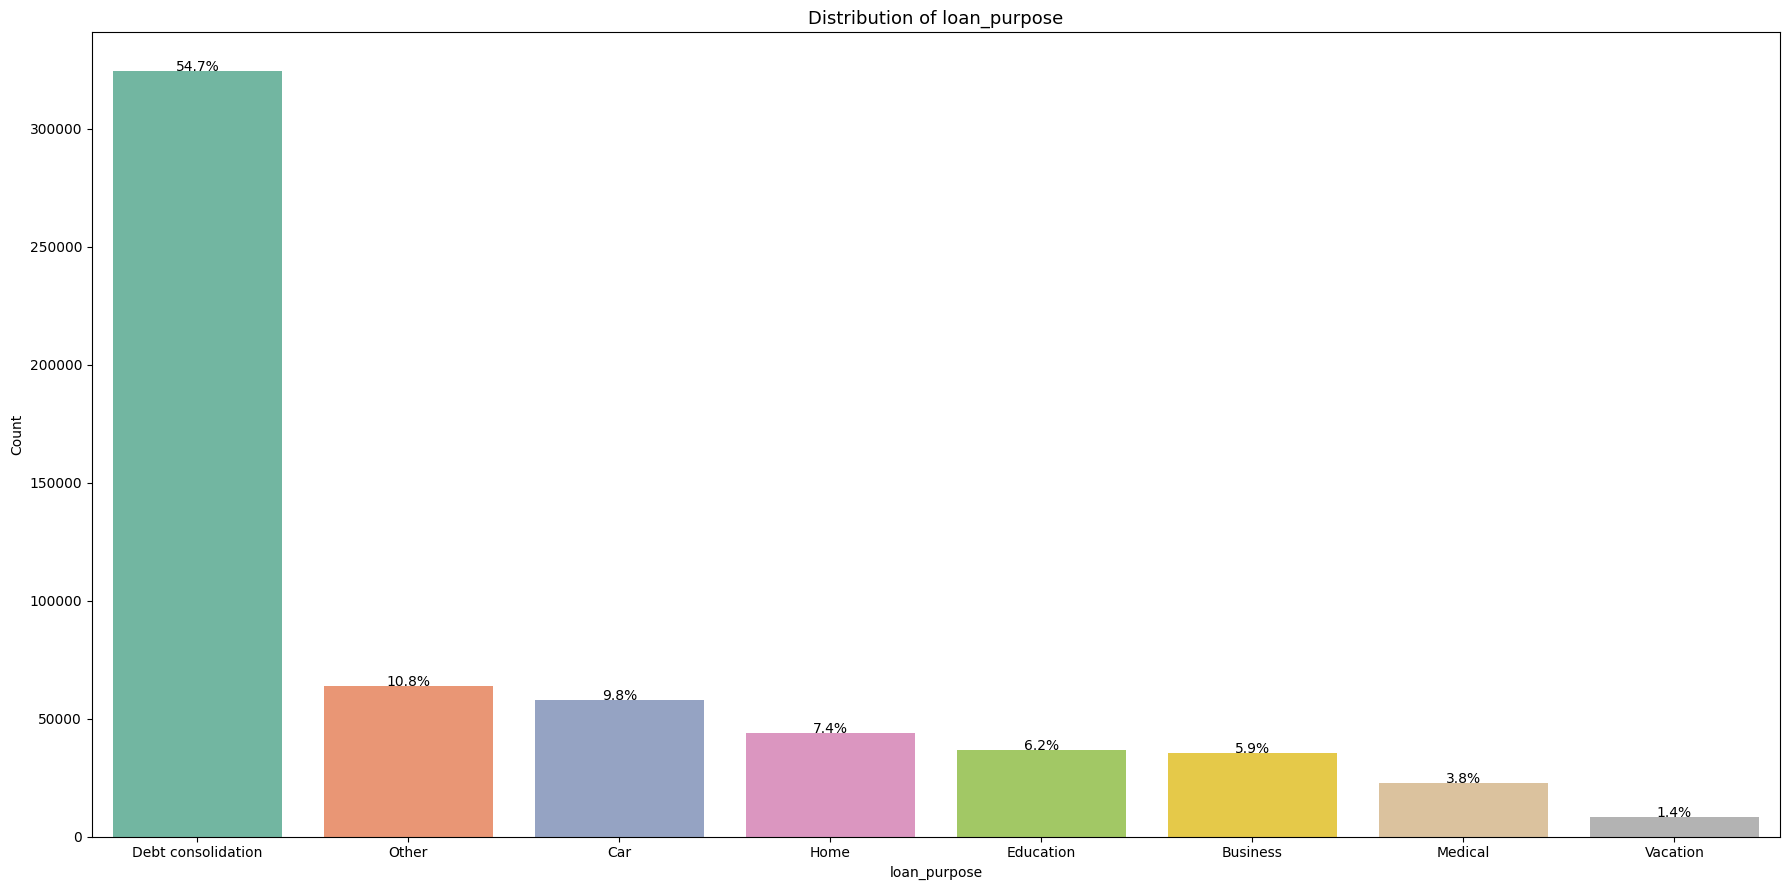

Feature: grade_subgrade
                Count  Percentage
grade_subgrade                   
C3              58695        9.88
C4              55957        9.42
C2              54443        9.17
C1              53363        8.98
C5              53317        8.98
D1              37029        6.23
D3              36694        6.18
D4              35097        5.91
D2              34432        5.80
D5              32101        5.40
B2              15167        2.55
B1              14344        2.41
B5              13937        2.35
B3              13926        2.34
B4              13877        2.34
E4               8036        1.35
E3               7075        1.19
E1               6891        1.16
E2               6372        1.07
E5               6084        1.02
F5               5947        1.00
F4               5535        0.93
F1               5534        0.93
F2               5203        0.88
F3               5082        0.86
A5               2471        0.42
A3               2066   

C:\Users\User\AppData\Local\Temp\ipykernel_4204\572669563.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='Set2', order=freq.index,color='teal')


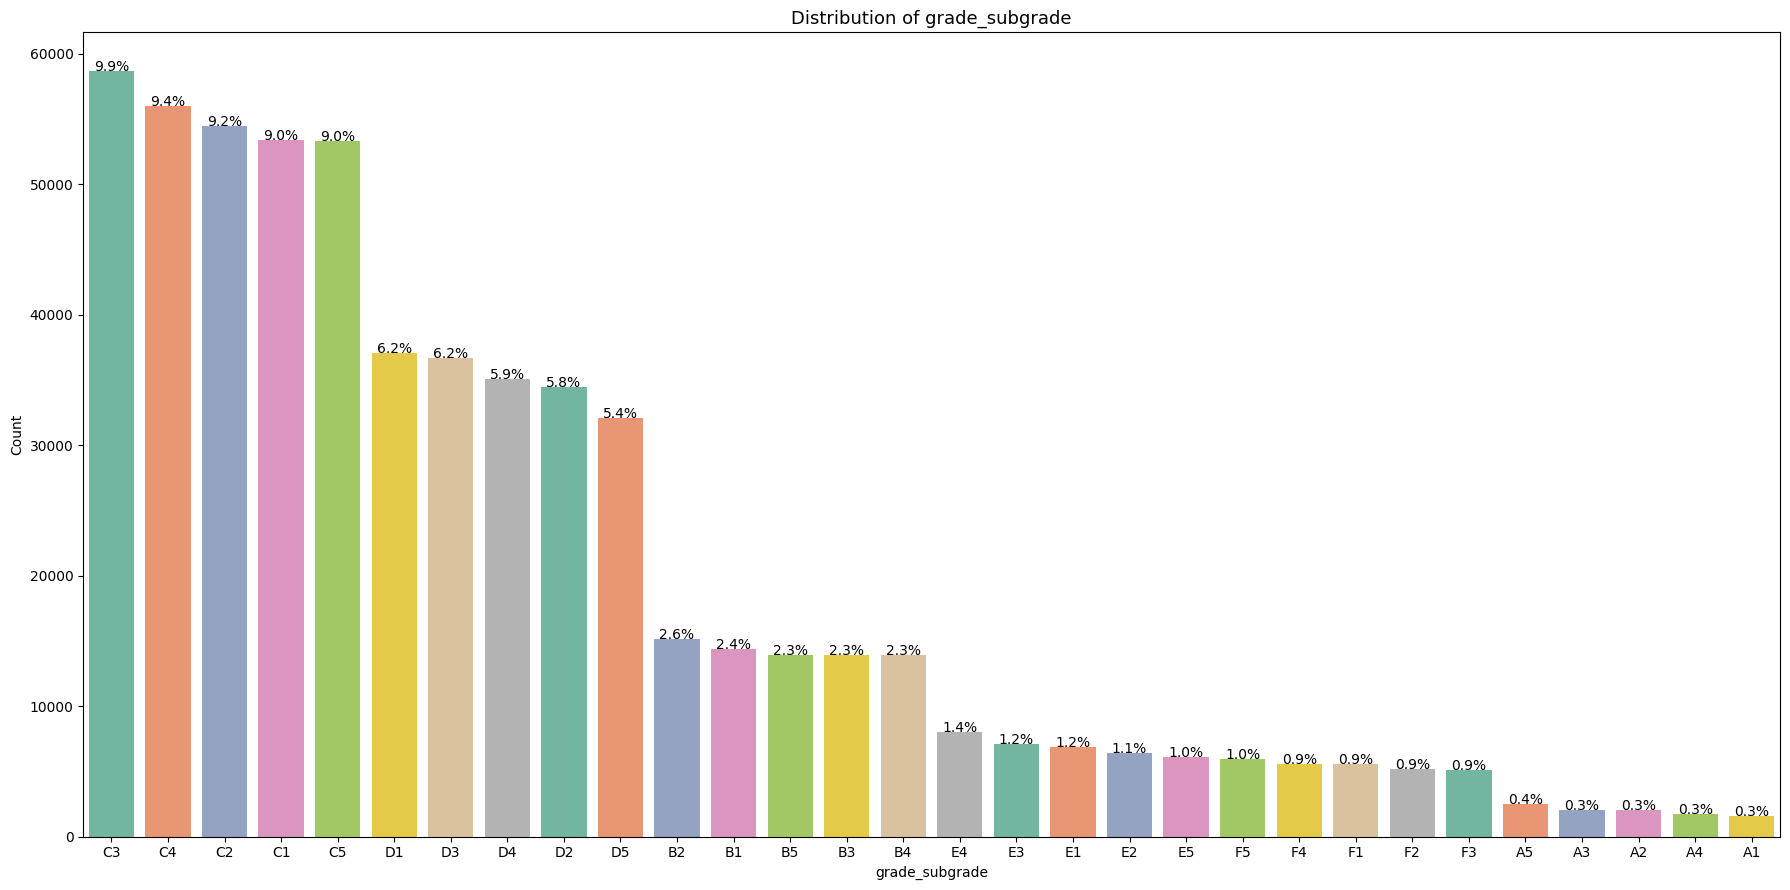

In [27]:
for col in cat_col:
    univariate_categories(df, col)


In [28]:
df.to_csv("cleaned_loan_dataset.csv", index=False)

Preprocessing 